In [ ]:
# !wget https://huggingface.co/neZorinEgor/data/resolve/main/data.zip -O data.zip
# !unzip data.zip

In [3]:
import os
from copy import deepcopy


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchview import draw_graph
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    mean_absolute_percentage_error,
    root_mean_squared_error,
    mean_absolute_error,
)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device=}")

device='cuda'


In [5]:
dataset = pd.read_csv("../../../data/datasets/train_val_1995-2018.csv")
dataset = dataset.drop(columns=["Unnamed: 0"])
dataset['datetime'] = pd.to_datetime(
    dataset['Year'].astype(str) + '-' +
    dataset['Decimal Day'].astype(str) +
    ' ' +
    dataset['Hour'].astype(str),
    format='%Y-%j %H'
)
dataset = dataset.drop(columns=["Year", "Decimal Day", "Hour"])
cols = ['datetime'] + [col for col in dataset.columns if col != 'datetime']
dataset = dataset[cols]
dataset.head()

,datetime,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,Dst,AE
0,1995-01-01 00:00:00,-1.2,3.6,-0.6,10,72.9,-6,25,15816.0,16.3,315.0,-0.4,4.6,-2,32
1,1995-01-01 01:00:00,-0.7,2.6,-0.9,10,72.9,-11,26,15601.0,18.8,315.0,-0.1,3.1,3,38
2,1995-01-01 02:00:00,0.0,1.8,0.5,10,72.9,-12,20,20703.0,19.3,320.0,0.3,2.1,6,34
3,1995-01-01 03:00:00,0.7,2.4,-3.2,0,72.9,-11,24,25094.0,16.4,317.0,1.6,2.2,5,36
4,1995-01-01 04:00:00,0.5,2.1,-4.3,0,72.9,-10,19,25604.0,14.5,313.0,1.7,2.2,3,31


In [6]:
fill_values = {
    "Bz_GSM": 999.9,
    "By_GSM": 999.9,
    "Bx_GSE": 999.9,
    "Kp": 99,
    "f10.7": 999.9,
    "AL": 99999,
    "AU": 99999,
    "T_proton": 9999999.,
    "Np_density": 999.9,
    "V_plasma": 9999.,
    "V_Long_GSE": 999.9,
    "V_Lat_GSE": 999.9,
    "Dst": 99999,
    "AE": 9999,
}
for col in dataset.drop(columns=["datetime"]).columns:
    dataset[col] = dataset[col].replace(fill_values[col], np.nan)

In [7]:
clean_dataset = dataset.copy()
features = [i for i in clean_dataset.columns if i != "datetime"]
clean_dataset[features] = clean_dataset[features].interpolate(method="pchip")
clean_dataset.head()

,datetime,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,Dst,AE
0,1995-01-01 00:00:00,-1.2,3.6,-0.6,10,72.9,-6,25,15816.0,16.3,315.0,-0.4,4.6,-2,32
1,1995-01-01 01:00:00,-0.7,2.6,-0.9,10,72.9,-11,26,15601.0,18.8,315.0,-0.1,3.1,3,38
2,1995-01-01 02:00:00,0.0,1.8,0.5,10,72.9,-12,20,20703.0,19.3,320.0,0.3,2.1,6,34
3,1995-01-01 03:00:00,0.7,2.4,-3.2,0,72.9,-11,24,25094.0,16.4,317.0,1.6,2.2,5,36
4,1995-01-01 04:00:00,0.5,2.1,-4.3,0,72.9,-10,19,25604.0,14.5,313.0,1.7,2.2,3,31


In [8]:
df = clean_dataset.copy()
df['hour'] = df['datetime'].dt.hour
df['day_of_year'] = df['datetime'].dt.dayofyear
df['day_of_week'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
# Циклическое преобразование (sin/cos) для часов
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
# Циклическое преобразование для дня года
df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
# Циклическое преобразование для дня недели
df['week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df = df.drop(columns=['hour', 'day_of_year', 'day_of_week', 'month'])

In [9]:
# oulu_df = pd.read_csv("/home/zorinep/workdir/magnesis/data/processed/oulu/oulu_1995_2018.csv", header=None, sep=";")
# oulu_df.columns = ["Timestamp", "CorrectedCountRate[cts/min]"]
# oulu_df["Timestamp"] = pd.to_datetime(oulu_df["Timestamp"])
# oulu_df["Timestamp"] = oulu_df["Timestamp"].dt.tz_localize(None)
# oulu_df.loc[
#     (oulu_df["CorrectedCountRate[cts/min]"] <= 5_000) | 
#     (oulu_df["CorrectedCountRate[cts/min]"] >= 7_000),
#     "CorrectedCountRate[cts/min]"
# ] = np.nan
# oulu_df =  oulu_df[oulu_df["Timestamp"] <= str(df["datetime"].max())]
# oulu_df["CorrectedCountRate[cts/min]"] = oulu_df["CorrectedCountRate[cts/min]"].interpolate("pchip")
# oulu_df = oulu_df.bfill()
# oulu_df.rename(columns={"Timestamp": "datetime"}, inplace=True)
# plt.figure(figsize=(16, 5))
# plt.plot(oulu_df["CorrectedCountRate[cts/min]"])
# plt.grid()
# plt.show()

In [10]:
# jung_df = pd.read_csv("/home/zorinep/workdir/magnesis/data/processed/jung/jung_1995_2018.csv", header=None, sep=";")
# jung_df.columns = ["datetime", "jung_flux"]
# jung_df.loc[
#     (jung_df["jung_flux"] <= 5_000) |
#     (jung_df["jung_flux"] >= 13_000),
#     "jung_flux"
# ] = np.nan
# jung_df["datetime"] = pd.to_datetime(jung_df["datetime"])
# jung_df =  jung_df[jung_df["datetime"] <= str(df["datetime"].max())]
# jung_df["jung_flux"] = jung_df["jung_flux"].interpolate("pchip")
# jung_df = jung_df.bfill()
# plt.figure(figsize=(16, 5))
# plt.plot(jung_df["jung_flux"])
# plt.grid()
# plt.show()

In [11]:
# tmp_df = pd.merge(
#     df,
#     oulu_df[["datetime", "CorrectedCountRate[cts/min]"]],
#     how="outer",
#     on="datetime"
# )
# merged_df = pd.merge(
#     tmp_df,
#     jung_df,
#     how="outer",
#     on="datetime"
# )
# merged_df[["CorrectedCountRate[cts/min]", "jung_flux"]] = merged_df[["CorrectedCountRate[cts/min]", "jung_flux"]].interpolate(method="pchip")
# merged_df = merged_df.bfill()
# merged_df.head()

In [12]:
# plt.style.use('seaborn-v0_8-whitegrid')
# sns.set_context("paper", font_scale=1.2)
# sns.set_palette("Set2")  # Спокойная палитра

# hours = np.linspace(0, 23, 24)
# hour_sin = np.sin(2 * np.pi * hours / 24)
# hour_cos = np.cos(2 * np.pi * hours / 24)

# days = np.linspace(0, 365, 366)
# day_sin = np.sin(2 * np.pi * days / 365.25)
# day_cos = np.cos(2 * np.pi * days / 365.25)
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ax1 = axes[0]
# ax1.scatter(hour_sin, hour_cos, c=hours, cmap='viridis', s=50, alpha=0.8)
# ax1.set_xlabel('sin(2π·hour/24)', fontsize=12)
# ax1.set_ylabel('cos(2π·hour/24)', fontsize=12)
# ax1.set_title('Циклическое кодирование времени суток', fontsize=14)
# ax1.grid(True, alpha=0.3)
# ax1.set_aspect('equal')

# # Добавляем подписи для некоторых точек
# for h in [0, 6, 12, 18]:
#     idx = int(h)
#     ax1.annotate(f'{h}:00', 
#                 (hour_sin[idx], hour_cos[idx]),
#                 xytext=(5, 5), textcoords='offset points',
#                 fontsize=10, alpha=0.7)

# # Дни года
# ax2 = axes[1]
# scatter = ax2.scatter(day_sin, day_cos, c=days, cmap='plasma', s=20, alpha=0.6)
# ax2.set_xlabel('sin(2π·day/365.25)', fontsize=12)
# ax2.set_ylabel('cos(2π·day/365.25)', fontsize=12)
# ax2.set_title('Циклическое кодирование дня года', fontsize=14)
# ax2.grid(True, alpha=0.3)
# ax2.set_aspect('equal')

# # Colorbar для второго графика
# cbar = plt.colorbar(scatter, ax=ax2)
# cbar.set_label('День года', fontsize=10)

# plt.tight_layout()
# plt.savefig('cyclic_encoding.png', dpi=300, bbox_inches='tight')
# plt.show()

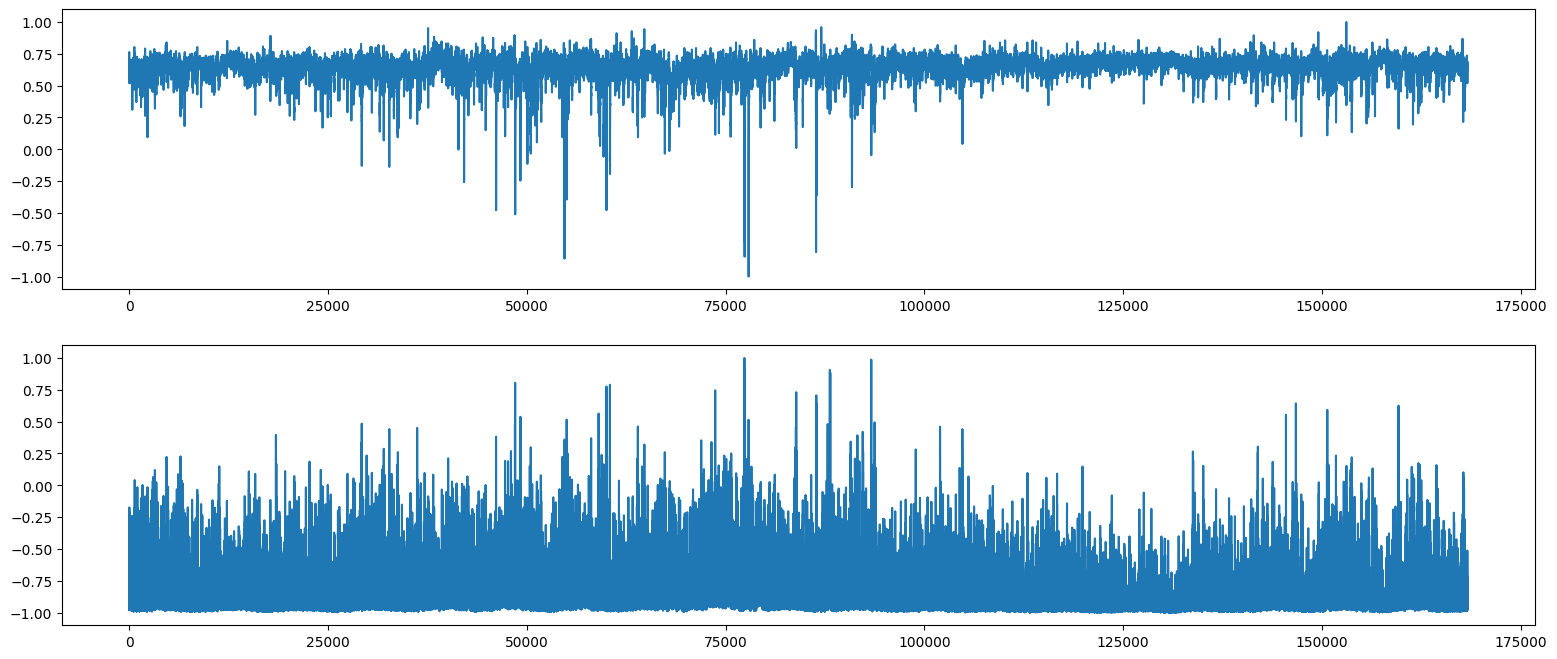

In [13]:
dataset_to_preprocess = df.copy()

# train/val 80/20
train_size = int(len(dataset_to_preprocess) * 0.8)
train = dataset_to_preprocess.iloc[:train_size]
test = dataset_to_preprocess.iloc[train_size:]
X_train = train.drop(columns=["datetime", "Dst"])
y_train = train[["Dst", "AE"]]
X_test = test.drop(columns=["datetime", "Dst"])
y_test = test[["Dst", "AE"]]

X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_scaler = MinMaxScaler(feature_range=(-1, 1))
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

_, axes = plt.subplots(2, 1, figsize=(19, 8))
axes[0].plot(y_train_scaled[:, 0])
axes[1].plot(y_train_scaled[:, 1])

In [14]:
class GeomagneticDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        X,
        y,
        X_window_size: int,
        y_window_size: int,
        stride: int = 1,
    ):
        self.X = torch.FloatTensor(X) if not isinstance(X, torch.Tensor) else X
        self.y = torch.FloatTensor(y) if not isinstance(y, torch.Tensor) else y
        self.X_window_size = X_window_size
        self.y_window_size = y_window_size
        self.stride = stride

        assert len(self.X) == len(self.y), "X and y must have same length"

        total_window = X_window_size + y_window_size
        self.num_samples = (len(self.X) - total_window) // stride + 1
        assert self.num_samples > 0, "Not enough data for windows"

    def __len__(self) -> int:
        return self.num_samples

    def __getitem__(self, index):
        start_idx = index * self.stride

        x_end_idx = start_idx + self.X_window_size
        x_window = self.X[start_idx:x_end_idx]

        y_start_idx = x_end_idx
        y_end_idx = y_start_idx + self.y_window_size
        y_window = self.y[y_start_idx:y_end_idx]  # [y_window_size, 2]

        y_6h = y_window[-1, :]  
        return x_window, y_6h.unsqueeze(0)  # [1, 2]

In [32]:
def inference_on_loader_pipeline(model, loader, y_scaler, device='cuda', visualize: bool = False, title_prefix='', until=-1):
    dst_labels = []
    dst_preds = []
    ae_labels = []
    ae_preds = []

    with torch.no_grad():
        model.eval()
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            dst_pred, ae_pred, _ = model(x)
            

            dst_pred = dst_pred.squeeze(1)  
            ae_pred = ae_pred.squeeze(1)   
            
            dst_true = y[:, 0, 0]  # [batch]
            ae_true = y[:, 0, 1]   # [batch]
            
            dst_preds.extend(dst_pred.cpu().numpy())
            ae_preds.extend(ae_pred.cpu().numpy())
            dst_labels.extend(dst_true.cpu().numpy())
            ae_labels.extend(ae_true.cpu().numpy())
    
    dst_preds = np.array(dst_preds)
    ae_preds = np.array(ae_preds)
    dst_labels = np.array(dst_labels)
    ae_labels = np.array(ae_labels)
    
    dst_pred_scaled = dst_preds.reshape(-1, 1)
    dst_true_scaled = dst_labels.reshape(-1, 1)
    ae_pred_scaled = ae_preds.reshape(-1, 1)
    ae_true_scaled = ae_labels.reshape(-1, 1)
    
    preds_combined = np.hstack([dst_pred_scaled, ae_pred_scaled])
    true_combined = np.hstack([dst_true_scaled, ae_true_scaled])
    
    preds_original = y_scaler.inverse_transform(preds_combined)
    true_original = y_scaler.inverse_transform(true_combined)
    
    dst_preds_orig = preds_original[:, 0][:until]
    ae_preds_orig = preds_original[:, 1][:until]
    dst_labels_orig = true_original[:, 0][:until]
    ae_labels_orig = true_original[:, 1][:until]
    
    # Метрики
    dst_rmse = np.sqrt(np.mean((dst_labels_orig - dst_preds_orig) ** 2))
    dst_mae = np.mean(np.abs(dst_labels_orig - dst_preds_orig))
    ae_rmse = np.sqrt(np.mean((ae_labels_orig - ae_preds_orig) ** 2))
    ae_mae = np.mean(np.abs(ae_labels_orig - ae_preds_orig))
    if visualize:
        _, axes = plt.subplots(2, 1, figsize=(16, 12))
        
        axes[0].plot(dst_labels_orig, label='Истинные значения', color='#1f77b4', linewidth=1.5)
        axes[0].plot(dst_preds_orig, label='Прогноз', color='#ff7f0e', linewidth=1.5)
        axes[0].set_title(f'{title_prefix} Dst', fontsize=12)
        axes[0].set_xlabel('Временные шаги (часы)')
        axes[0].set_ylabel('Dst, nT')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        axes[0].text(0.02, 0.95, f'RMSE = {dst_rmse:.2f} nT\nMAE = {dst_mae:.2f} nT', 
                    transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        axes[1].plot(ae_labels_orig, label='Истинные значения', color='#1f77b4', linewidth=1.5)
        axes[1].plot(ae_preds_orig, label='Прогноз', color='#ff7f0e', linewidth=1.5)
        axes[1].set_title(f'{title_prefix} AE', fontsize=12)
        axes[1].set_xlabel('Временные шаги (часы)')
        axes[1].set_ylabel('AE, nT')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        axes[1].text(0.02, 0.95, f'RMSE = {ae_rmse:.2f} nT\nMAE = {ae_mae:.2f} nT', 
                    transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.suptitle(f'{title_prefix} Прогноз геомагнитных индексов', fontsize=14)
        plt.tight_layout()
        plt.show()
        
        print(f"{title_prefix} Результаты прогноза")
        print(f"Dst: RMSE = {dst_rmse:.2f} nT, MAE = {dst_mae:.2f} nT")
        print(f"AE:  RMSE = {ae_rmse:.2f} nT, MAE = {ae_mae:.2f} nT")
        
    return {
        'dst_rmse': dst_rmse,
        'dst_mae': dst_mae,
        'ae_rmse': ae_rmse,
        'ae_mae': ae_mae,
        'dst_preds': dst_preds_orig,
        'dst_labels': dst_labels_orig,
        'ae_preds': ae_preds_orig,
        'ae_labels': ae_labels_orig,
    }

In [16]:
def draw_dst_storm_prediction(inference_on_loader_result, storm_threshold, padding, min_duration, min_depth, above=False):
    def find_storm_periods(labels, threshold, padding, min_duration, min_depth, above=False):
        if above:
            mask = labels > threshold
        else:
            mask = labels < threshold  
        
        periods = []
        i = 0
        while i < len(mask):
            if mask[i]:
                start = i
                while i < len(mask) and mask[i]:
                    i += 1
                end = i - 1
                
                duration = end - start + 1
                if above:
                    max_val = np.max(labels[start:end+1])
                    depth = max_val - threshold
                else:
                    min_val = np.min(labels[start:end+1])
                    depth = threshold - min_val  # Глубина для Dst
                
                if duration >= min_duration and depth >= min_depth:
                    start_pad = max(0, start - padding)
                    periods.append((start_pad, end))
            else:
                i += 1
        return periods

    labels_full = np.array(inference_on_loader_result["dst_labels"])
    dst_periods = find_storm_periods(
        labels_full, 
        threshold=storm_threshold, 
        padding=padding,
        min_duration=min_duration,
        min_depth=min_depth,
        above=above  # Используем параметр функции
    )

    f1s = []
    for period in dst_periods:
        from_ = period[0]
        to = period[1]

        labels = np.array(inference_on_loader_result["dst_labels"][from_:to])
        preds = np.array(inference_on_loader_result["dst_preds"][from_:to])
        indices = np.arange(from_, to)
        
        # Для Dst: буря когда значения НИЖЕ порога
        storm_mask = labels < storm_threshold
        pred_storm_mask = preds < storm_threshold
        
        plt.figure(figsize=(18, 5))
        plt.plot(indices, labels, label='Истинные значения', color='#1f77b4', linewidth=1.5)
        plt.plot(indices, preds, label='Прогноз', color='#ff7f0e', linewidth=1.5)
        
        # Фактические бури
        storm_indices = indices[storm_mask]
        storm_values = labels[storm_mask]
        plt.scatter(storm_indices, storm_values, 
                    color='red', s=50, zorder=5, 
                    label=f'Фактическая буря (Dst < {storm_threshold} nT)', alpha=0.7)
        
        # Предсказанные бури
        pred_storm_indices = indices[pred_storm_mask]
        pred_storm_values = preds[pred_storm_mask]
        plt.scatter(pred_storm_indices, pred_storm_values, 
                    color='green', s=50, zorder=5, marker='s',
                    label=f'Модель предсказала бурю (Dst < {storm_threshold} nT)', alpha=0.7)
        
        plt.axhline(y=storm_threshold, color='red', linestyle='--', alpha=0.5, label=f'Порог {storm_threshold} nT')
        
        # Закрашиваем области бурь
        for i in range(len(storm_mask)):
            if storm_mask[i]:
                plt.axvspan(indices[i]-0.5, indices[i]+0.5, alpha=0.15, color='red', zorder=0)
        
        plt.grid(True, alpha=0.3)
        plt.legend(loc='upper left')
        plt.title(f'Dst: прогноз vs факт с выделением бурь (Dst < {storm_threshold} nT)')
        plt.xlabel('Временные шаги')
        plt.ylabel('Dst, nT')
        plt.tight_layout()
        plt.show()
        
        # Статистика
        print(f"=== Статистика по бурям (Dst < {storm_threshold} nT) ===")
        print(f"Всего моментов с бурей по факту: {np.sum(storm_mask)}")
        print(f"Всего моментов, когда модель предсказала бурю: {np.sum(pred_storm_mask)}")
        
        true_positives = np.sum(storm_mask & pred_storm_mask)
        false_positives = np.sum((~storm_mask) & pred_storm_mask)
        false_negatives = np.sum(storm_mask & (~pred_storm_mask))

        precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
        recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0

        print(f"Precision: {precision:.3f}")
        print(f"Recall: {recall:.3f}")

        if precision + recall > 0:
            f1 = 2 * precision * recall / (precision + recall)
            print(f"F1: {f1:.3f}")
            f1s.append(f1)
    if f1s:
        print(f"\nСредний F1 по всем бурям: {sum(f1s)/len(f1s):.3f}")
    else:
        print("\nНе найдено ни одного периода бури!")
    return f1s

In [17]:
def make_dataset(
    path,
    x_scaler,
    y_scaler,
    oulu_path=None,
    jung_path=None,
    X_window_size=24*7,
    y_window_size=6,
    batch_size=32,
    stride=6,
    columns_to_drop=None,
    use_time_feature=True
):
    dataset = pd.read_csv(path)
    dataset = dataset.drop(columns=["Unnamed: 0"])
    dataset['datetime'] = pd.to_datetime(
        dataset['Year'].astype(str) + '-' +
        dataset['Decimal Day'].astype(str) +
        ' ' +
        dataset['Hour'].astype(str),
        format='%Y-%j %H'
    )
    dataset = dataset.drop(columns=["Year", "Decimal Day", "Hour"])
    if columns_to_drop:
        dataset = dataset.drop(columns=columns_to_drop)
    cols = ['datetime'] + [col for col in dataset.columns if col != 'datetime']
    dataset = dataset[cols]

    fill_values = {
        "Bz_GSM": 999.9,
        "By_GSM": 999.9,
        "Bx_GSE": 999.9,
        "Kp": 99,
        "f10.7": 999.9,
        "AL": 99999,
        "AU": 99999,
        "T_proton": 9999999.,
        "Np_density": 999.9,
        "V_plasma": 9999.,
        "V_Long_GSE": 999.9,
        "V_Lat_GSE": 999.9,
        "Dst": 99999,
        "AE": 9999,
    }
    for col in dataset.drop(columns=["datetime"]).columns:
        dataset[col] = dataset[col].replace(fill_values[col], np.nan)

    clean_dataset = dataset.copy()
    features = [i for i in clean_dataset.columns if i != "datetime"]
    clean_dataset[features] = clean_dataset[features].interpolate(method="pchip")
    df = clean_dataset.copy()
    if use_time_feature:
        df['hour'] = df['datetime'].dt.hour
        df['day_of_year'] = df['datetime'].dt.dayofyear
        df['day_of_week'] = df['datetime'].dt.dayofweek
        df['month'] = df['datetime'].dt.month
        df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
        df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
        df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
        df['week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
        df['week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
        df = df.drop(columns=['hour', 'day_of_year', 'day_of_week', 'month'])
    if oulu_path is not None:
        oulu_df = pd.read_csv(oulu_path, header=None, sep=";")
        oulu_df.columns = ["Timestamp", "CorrectedCountRate[cts/min]"]
        oulu_df["Timestamp"] = pd.to_datetime(oulu_df["Timestamp"])
        oulu_df["Timestamp"] = oulu_df["Timestamp"].dt.tz_localize(None)
        oulu_df.loc[
            (oulu_df["CorrectedCountRate[cts/min]"] <= 5_000) | 
            (oulu_df["CorrectedCountRate[cts/min]"] >= 7_000),
            "CorrectedCountRate[cts/min]"
        ] = np.nan
        oulu_df =  oulu_df[oulu_df["Timestamp"] <= str(df["datetime"].max())]
        oulu_df.rename(columns={"Timestamp": "datetime"}, inplace=True)
        oulu_df["CorrectedCountRate[cts/min]"] = oulu_df["CorrectedCountRate[cts/min]"].interpolate("pchip")
        oulu_df = oulu_df.bfill()
        df = pd.merge(
            df,
            oulu_df[["datetime", "CorrectedCountRate[cts/min]"]],
            how="outer",
            on="datetime"
        )
    if jung_path is not None:
        jung_df = pd.read_csv(jung_path, header=None, sep=";")
        jung_df.columns = ["datetime", "jung_flux"]
        jung_df["jung_flux"] = jung_df["jung_flux"]/3
        jung_df.loc[
            (jung_df["jung_flux"] <= 5_000) |
            (jung_df["jung_flux"] >= 13_000),
            "jung_flux"
        ] = np.nan
        jung_df["datetime"] = pd.to_datetime(jung_df["datetime"])
        jung_df =  jung_df[jung_df["datetime"] <= str(df["datetime"].max())]
        jung_df["jung_flux"] = jung_df["jung_flux"].interpolate("pchip")
        jung_df = jung_df.bfill()
        df = pd.merge(
            df,
            jung_df[["datetime", "jung_flux"]],
            how="outer",
            on="datetime"
        )

    dataset_to_preprocess = df.copy()

    X_test, y_test = dataset_to_preprocess.drop(columns=["datetime", "Dst"]), dataset_to_preprocess[["Dst", "AE"]]

    X_test_scaled = x_scaler.transform(X_test)

    y_test_scaled = y_scaler.transform(y_test)
    test_dataset = GeomagneticDataset(
        X=X_test_scaled,
        y=y_test_scaled,
        X_window_size=X_window_size,
        y_window_size=y_window_size,
        stride=stride,
    )
    val_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return val_loader

In [18]:
class GeomagneticModel(nn.Module):
    def __init__(
        self,
        n_features,
        lstm_hidden_size,
        lstm_num_layers,
        lstm_dropout,
        dst_attention_heads,
        ae_attention_heads,
    ):
        super().__init__()

        self.dst_lstm = nn.LSTM(
            n_features, lstm_hidden_size, lstm_num_layers,
            dropout=lstm_dropout, batch_first=True
        )
        self.ae_lstm = nn.LSTM(
            n_features, lstm_hidden_size, lstm_num_layers,
            dropout=lstm_dropout, batch_first=True
        )

        self.dst_attention = nn.MultiheadAttention(
            lstm_hidden_size, dst_attention_heads,
            dropout=lstm_dropout, batch_first=True
        )
        self.ae_attention = nn.MultiheadAttention(
            lstm_hidden_size, ae_attention_heads,
            dropout=lstm_dropout, batch_first=True
        )
        
        self.dst_attention_norm = nn.LayerNorm(lstm_hidden_size)
        self.ae_attention_norm = nn.LayerNorm(lstm_hidden_size)

        self.dropout = nn.Dropout(lstm_dropout)
        heads_hidden_size = lstm_hidden_size
        
        self.dst_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, 1),
        )

        self.ae_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, 1),
        )

    def forward(self, x):
        dst_out, _ = self.dst_lstm(x)
        dst_query = dst_out[:, -1:, :]
        dst_attn_out, dst_attn_w = self.dst_attention(
            dst_query, dst_out, dst_out
        )
        dst_features = self.dst_attention_norm(
            dst_query.squeeze(1) + dst_attn_out.squeeze(1)
        )
        dst_features = self.dropout(dst_features)
        dst = self.dst_head(dst_features)

        ae_out, _ = self.ae_lstm(x)
        ae_query = ae_out[:, -1:, :]
        ae_attn_out, ae_attn_w = self.ae_attention(
            ae_query, ae_out, ae_out
        )
        ae_features = self.ae_attention_norm(
            ae_query.squeeze(1) + ae_attn_out.squeeze(1)
        )
        ae_features = self.dropout(ae_features)
        ae = self.ae_head(ae_features)

        return dst, ae, (dst_attn_w, ae_attn_w)

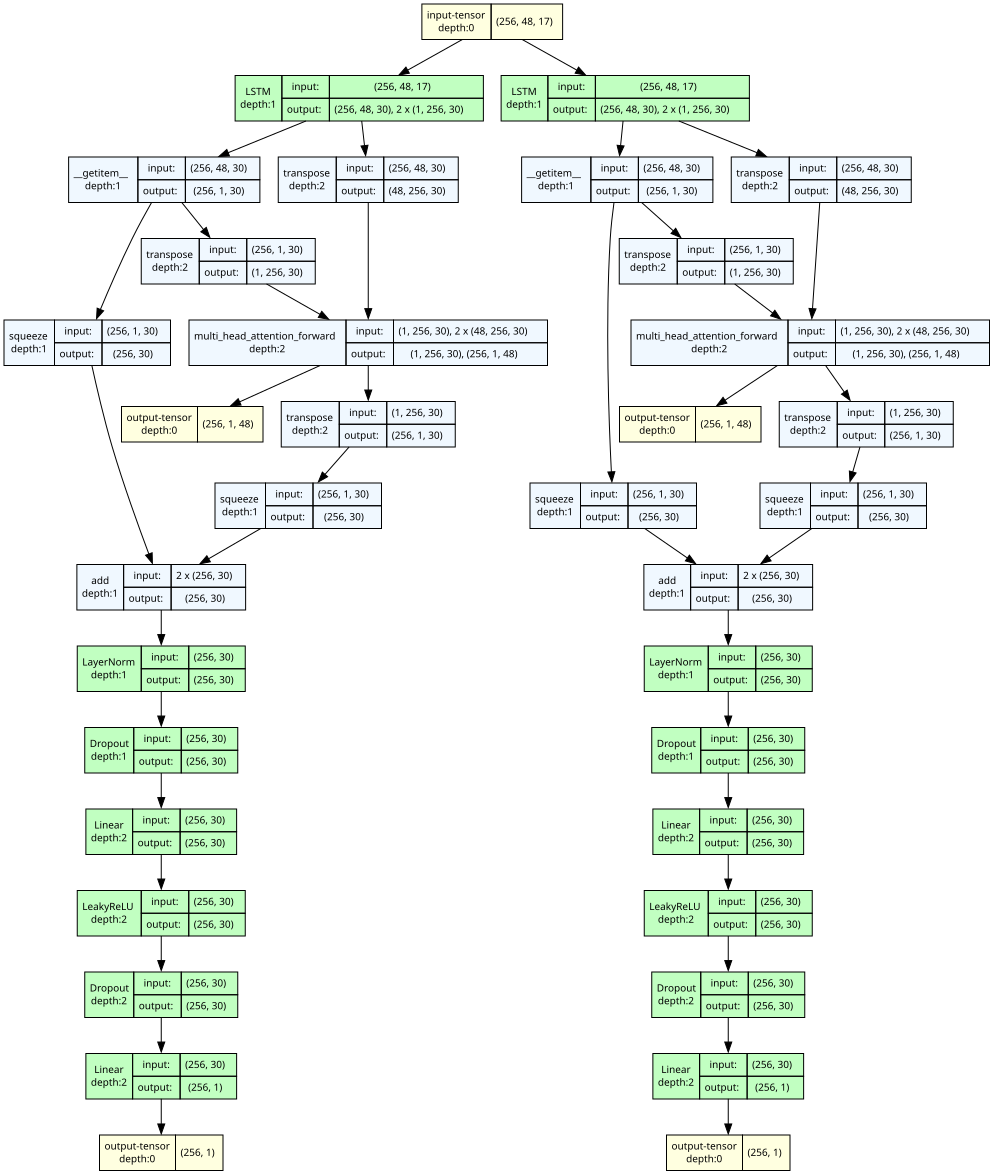

In [19]:
BATCH_SIZE = 256
N_FEATURES = 17
X_WINDOW_SIZE = 24*2

best_model_35 = GeomagneticModel(n_features=N_FEATURES, lstm_hidden_size=30, lstm_num_layers=1, lstm_dropout=0.0,  dst_attention_heads=10, ae_attention_heads=30).to(device)
graph = draw_graph(
    model=best_model_35,
    input_size=(BATCH_SIZE, X_WINDOW_SIZE, N_FEATURES)
)
graph.visual_graph

In [ ]:
from scipy.special import inv_boxcox


def train_geomagnetic_model(
    model,
    loss_fn,
    optimizer,
    lr_scheduler,
    epochs,
    train_loader,
    val_loader,
    y_scaler,
    log_ae,
    patience,
    patience_delta=1e-4,
    stop_metric='loss',
    dst_loss_sigma=1.0,
    ae_loss_sigma=1.0,
    device="cuda",
    save_dir="./models"
):
    os.makedirs(save_dir, exist_ok=True)

    patience_counter = 0
    
    best_val_loss = float('inf')
    best_val_dst_rmse = float('inf')
    best_val_ae_rmse = float('inf')
    
    best_stop_metric = float('inf')
    
    best_epoch = 0
    best_dst_epoch = 0
    best_ae_epoch = 0

    history_train = {
        "lr": [],
        "dst_loss": [],
        "ae_loss": [],
        "summary_loss": [],
        "ae": {"RMSE": [], "MAPE": [], "MAE": []},
        "dst": {"RMSE": [], "MAPE": [], "MAE": []}
    }
    history_val = {
        "loss": [],
        "ae": {"RMSE": [], "MAPE": [], "MAE": []},
        "dst": {"RMSE": [], "MAPE": [], "MAE": []}
    }

    model.to(device)

    for e in range(epochs):
        model.train()
        train_progress = tqdm(train_loader)
        running_history = {
            "dst_loss": [],
            "ae_loss": [],
            "summary_loss": [],
            "ae": {"RMSE": [], "MAPE": [], "MAE": []},
            "dst": {"RMSE": [], "MAPE": [], "MAE": []}
        }

        for x, y in train_progress:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            # y имеет размер [batch, 1, 2]
            dst_y = y[:, 0, 0]  # [batch]
            ae_y = y[:, 0, 1]   # [batch]
            
            dst_y_pred, ae_y_pred, _ = model(x)
            dst_y_pred = dst_y_pred.squeeze(1)  # [batch]
            ae_y_pred = ae_y_pred.squeeze(1)    # [batch]

            dst_loss = loss_fn(dst_y_pred, dst_y)
            ae_loss = loss_fn(ae_y_pred, ae_y)
            loss = dst_loss * dst_loss_sigma + ae_loss_sigma * ae_loss

            loss.backward()
            optimizer.step()

            with torch.no_grad():
                last_dst = x[:, -1, -2]
                last_ae = x[:, -1, -1]
                
                dst_pred_abs = last_dst + dst_y_pred
                ae_pred_abs = last_ae + ae_y_pred
                dst_true_abs = last_dst + dst_y
                ae_true_abs = last_ae + ae_y
                
                pred_data = np.stack([dst_pred_abs.detach().cpu().numpy(),
                                     ae_pred_abs.detach().cpu().numpy()], axis=1)
                label_data = np.stack([dst_true_abs.detach().cpu().numpy(),
                                      ae_true_abs.detach().cpu().numpy()], axis=1)
                
                pred_data = y_scaler.inverse_transform(pred_data)
                label_data = y_scaler.inverse_transform(label_data)


                dst_rmse = root_mean_squared_error(label_data[:, 0], pred_data[:, 0])
                ae_rmse = root_mean_squared_error(label_data[:, 1], pred_data[:, 1])
                dst_mape = mean_absolute_percentage_error(label_data[:, 0], pred_data[:, 0])
                ae_mape = mean_absolute_percentage_error(label_data[:, 1], pred_data[:, 1])
                dst_mae = mean_absolute_error(label_data[:, 0], pred_data[:, 0])
                ae_mae = mean_absolute_error(label_data[:, 1], pred_data[:, 1])

                running_history["dst"]["RMSE"].append(dst_rmse)
                running_history["ae"]["RMSE"].append(ae_rmse)
                running_history["dst"]["MAPE"].append(dst_mape)
                running_history["ae"]["MAPE"].append(ae_mape)
                running_history["dst"]["MAE"].append(dst_mae)
                running_history["ae"]["MAE"].append(ae_mae)
                running_history["dst_loss"].append(dst_loss.item())
                running_history["ae_loss"].append(ae_loss.item())
                running_history["summary_loss"].append(loss.item())

            train_progress.set_description(
                f"Epoch [{e+1:>3}/{epochs}] [TRAIN] dst-RMSE {dst_rmse:.3f} ae-RMSE {ae_rmse:.3f} Loss {loss.item():.4f}"
            )
        
        history_train["lr"].append(lr_scheduler.get_last_lr())
        history_train["dst"]["RMSE"].append(np.mean(running_history["dst"]["RMSE"]))
        history_train["ae"]["RMSE"].append(np.mean(running_history["ae"]["RMSE"]))
        history_train["dst"]["MAPE"].append(np.mean(running_history["dst"]["MAPE"]))
        history_train["ae"]["MAPE"].append(np.mean(running_history["ae"]["MAPE"]))
        history_train["dst"]["MAE"].append(np.mean(running_history["dst"]["MAE"]))
        history_train["ae"]["MAE"].append(np.mean(running_history["ae"]["MAE"]))
        history_train["dst_loss"].append(np.mean(running_history["dst_loss"]))
        history_train["ae_loss"].append(np.mean(running_history["ae_loss"]))
        history_train["summary_loss"].append(np.mean(running_history["summary_loss"]))

        with torch.no_grad():
            model.eval()
            val_progress = tqdm(val_loader)
            running_val = {
                "loss": [],
                "ae": {"RMSE": [], "MAPE": [], "MAE": []},
                "dst": {"RMSE": [], "MAPE": [], "MAE": []}
            }

            for x, y in val_progress:
                x, y = x.to(device), y.to(device)
                
                dst_y = y[:, 0, 0]  # [batch]
                ae_y = y[:, 0, 1]   # [batch]
                
                dst_y_pred, ae_y_pred, _ = model(x)
                dst_y_pred = dst_y_pred.squeeze(1)  # [batch]
                ae_y_pred = ae_y_pred.squeeze(1)    # [batch]

                dst_loss = loss_fn(dst_y_pred, dst_y)
                ae_loss = loss_fn(ae_y_pred, ae_y)
                val_loss = dst_loss * dst_loss_sigma + ae_loss_sigma * ae_loss
                running_val["loss"].append(val_loss.item())

                last_dst = x[:, -1, -2]
                last_ae = x[:, -1, -1]
                
                dst_pred_abs = last_dst + dst_y_pred
                ae_pred_abs = last_ae + ae_y_pred
                dst_true_abs = last_dst + dst_y
                ae_true_abs = last_ae + ae_y
                
                pred_data = np.stack([dst_pred_abs.detach().cpu().numpy(),
                                     ae_pred_abs.detach().cpu().numpy()], axis=1)
                label_data = np.stack([dst_true_abs.detach().cpu().numpy(),
                                      ae_true_abs.detach().cpu().numpy()], axis=1)
                
                pred_data = y_scaler.inverse_transform(pred_data)
                label_data = y_scaler.inverse_transform(label_data)

                dst_rmse = root_mean_squared_error(label_data[:, 0], pred_data[:, 0])
                ae_rmse = root_mean_squared_error(label_data[:, 1], pred_data[:, 1])
                dst_mape = mean_absolute_percentage_error(label_data[:, 0], pred_data[:, 0])
                ae_mape = mean_absolute_percentage_error(label_data[:, 1], pred_data[:, 1])
                dst_mae = mean_absolute_error(label_data[:, 0], pred_data[:, 0])
                ae_mae = mean_absolute_error(label_data[:, 1], pred_data[:, 1])

                running_val["dst"]["RMSE"].append(dst_rmse)
                running_val["ae"]["RMSE"].append(ae_rmse)
                running_val["dst"]["MAPE"].append(dst_mape)
                running_val["ae"]["MAPE"].append(ae_mape)
                running_val["dst"]["MAE"].append(dst_mae)
                running_val["ae"]["MAE"].append(ae_mae)

                val_progress.set_description(
                    f"Epoch [{e+1:>3}/{epochs}] [VAL  ] dst-RMSE {dst_rmse:.3f} ae-RMSE {ae_rmse:.3f} Loss {val_loss.item():.4f}"
                )

            current_val_loss = np.mean(running_val["loss"])
            current_val_dst_rmse = np.mean(running_val["dst"]["RMSE"])
            current_val_ae_rmse = np.mean(running_val["ae"]["RMSE"])

            history_val["loss"].append(current_val_loss)
            history_val["dst"]["RMSE"].append(current_val_dst_rmse)
            history_val["ae"]["RMSE"].append(current_val_ae_rmse)
            history_val["dst"]["MAPE"].append(np.mean(running_val["dst"]["MAPE"]))
            history_val["ae"]["MAPE"].append(np.mean(running_val["ae"]["MAPE"]))
            history_val["dst"]["MAE"].append(np.mean(running_val["dst"]["MAE"]))
            history_val["ae"]["MAE"].append(np.mean(running_val["ae"]["MAE"]))

        lr_scheduler.step(metrics=current_val_loss)

        if current_val_loss < best_val_loss - patience_delta:
            best_val_loss = current_val_loss
            best_epoch = e + 1
            best_model_path = os.path.join(save_dir, f"best_model_loss_epoch_{best_epoch}_loss_{best_val_loss:.6f}.pt")
            torch.save(model.state_dict(), best_model_path)
            print(f"New best model by loss! Epoch {best_epoch}, Val Loss: {best_val_loss:.6f}")

        if current_val_dst_rmse < best_val_dst_rmse - (patience_delta * 0.1):
            best_val_dst_rmse = current_val_dst_rmse
            best_dst_epoch = e + 1
            best_dst_path = os.path.join(save_dir, f"best_model_dst_epoch_{best_dst_epoch}_rmse_{best_val_dst_rmse:.3f}.pt")
            torch.save(model.state_dict(), best_dst_path)
            print(f"New best model by DST RMSE! Epoch {best_dst_epoch}, DST RMSE: {best_val_dst_rmse:.3f}")

        if current_val_ae_rmse < best_val_ae_rmse - (patience_delta * 0.1):
            best_val_ae_rmse = current_val_ae_rmse
            best_ae_epoch = e + 1
            best_ae_path = os.path.join(save_dir, f"best_model_ae_epoch_{best_ae_epoch}_rmse_{best_val_ae_rmse:.3f}.pt")
            torch.save(model.state_dict(), best_ae_path)
            print(f"New best model by AE RMSE! Epoch {best_ae_epoch}, AE RMSE: {best_val_ae_rmse:.3f}")

        if stop_metric == 'loss':
            current_metric = current_val_loss
            metric_name = "Loss"
        elif stop_metric == 'dst_rmse':
            current_metric = current_val_dst_rmse
            metric_name = "DST RMSE"
        elif stop_metric == 'ae_rmse':
            current_metric = current_val_ae_rmse
            metric_name = "AE RMSE"
        elif stop_metric == 'combined':
            if e == 0:
                norm_loss = current_val_loss
                norm_dst = current_val_dst_rmse
                norm_ae = current_val_ae_rmse
            else:
                norm_loss = current_val_loss / history_val["loss"][0]
                norm_dst = current_val_dst_rmse / history_val["dst"]["RMSE"][0]
                norm_ae = current_val_ae_rmse / history_val["ae"]["RMSE"][0]
            current_metric = norm_loss + norm_dst + norm_ae
            metric_name = "Combined (Loss + DST + AE)"
        else:
            raise ValueError(f"Unknown stop_metric: {stop_metric}")

        if current_metric < best_stop_metric - patience_delta:
            best_stop_metric = current_metric
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter > 0:
            print(f"Early stopping patience: {patience_counter}/{patience} (best {metric_name}: {best_stop_metric:.6f}, current: {current_metric:.6f})")

        if patience_counter >= patience:
            print(f"\n{'='*60}")
            print(f"EARLY STOPPING triggered at epoch {e+1}")
            print(f"Stopping metric: {metric_name}")
            print(f"Best {metric_name}: {best_stop_metric:.6f}")
            print(f"Current {metric_name}: {current_metric:.6f}")
            print(f"\nBest models:")
            print(f"  - Loss: epoch {best_epoch}, value: {best_val_loss:.6f}")
            print(f"  - DST RMSE: epoch {best_dst_epoch}, value: {best_val_dst_rmse:.3f}")
            print(f"  - AE RMSE: epoch {best_ae_epoch}, value: {best_val_ae_rmse:.3f}")
            print(f"{'='*60}")

            last_model_path = os.path.join(save_dir, "last_model.pt")
            torch.save(model.state_dict(), last_model_path)
            print(f"Last model saved to: {last_model_path}")
            break

    else:
        final_model_path = os.path.join(save_dir, "final_model.pt")
        torch.save(model.state_dict(), final_model_path)
        print(f"\nTraining completed! Final model saved to: {final_model_path}")
        print(f"Best model by loss at epoch {best_epoch} with val loss: {best_val_loss:.6f}")
        print(f"Best model by DST at epoch {best_dst_epoch} with RMSE: {best_val_dst_rmse:.3f}")
        print(f"Best model by AE at epoch {best_ae_epoch} with RMSE: {best_val_ae_rmse:.3f}")

    return model, history_train, history_val

In [21]:
BATCH_SIZE = 256
STRIDE = 1
X_WINDOW_SIZE = 24*2


loader_2019_2025 = make_dataset(
    path="/home/zorinep/workdir/magnesis/data/row/omni/test/data_2019_2025.csv",
    jung_path=None,
    oulu_path=None,
    # jung_path="/home/zorinep/workdir/magnesis/data/processed/jung/jung2025_scaled.csv",
    # oulu_path="/home/zorinep/workdir/magnesis/data/processed/oulu/oulu_2025.csv",
    x_scaler=X_scaler,
    y_scaler=y_scaler,
    X_window_size=X_WINDOW_SIZE,
    y_window_size=6,
    batch_size=BATCH_SIZE,
    stride=STRIDE,
    use_time_feature=True
)

In [22]:
from warnings import filterwarnings

filterwarnings("ignore")

In [ ]:
INITIAL_LR = 1e-4
EPOCHS = 3000
PATIENCE_DELTA = 1e-3
PATIENCE = 10
LR_SCHEDULER_FACTOR = 0.7      
LR_SCHEDULER_PATIENCE = 10     
LR_SCHEDULER_THRESHOLD = 1e-4  
LR_SCHEDULER_COOLDOWN = 5    
LR_SCHEDULER_MIN_LR = 1e-6     

Y_WINDOW_SIZE = 6
net = GeomagneticModel(
    n_features=19,
    lstm_hidden_size=30,
    lstm_num_layers=1,
    lstm_dropout=0.0,
    dst_attention_heads=5,
    ae_attention_heads=15,
)
print(f"Кол-во весов: {sum([i.numel() for i in net.parameters()])}")
loss_fn = nn.HuberLoss(delta=0.2)
optimizer = optim.AdamW(net.parameters(), lr=INITIAL_LR, weight_decay=0.01)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=LR_SCHEDULER_FACTOR,
    patience=LR_SCHEDULER_PATIENCE,
    threshold=LR_SCHEDULER_THRESHOLD,
    cooldown=LR_SCHEDULER_COOLDOWN,
    min_lr=LR_SCHEDULER_MIN_LR,
)

X_WINDOW_SIZE = 24*2
BATHCH_SIZE = 256
STRIDE = 1

train_dataset = GeomagneticDataset(X=X_train_scaled, y=y_train_scaled, X_window_size=X_WINDOW_SIZE, y_window_size=Y_WINDOW_SIZE, stride=STRIDE)
test_dataset = GeomagneticDataset(X=X_test_scaled, y=y_test_scaled, X_window_size=X_WINDOW_SIZE, y_window_size=Y_WINDOW_SIZE, stride=STRIDE)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATHCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATHCH_SIZE, shuffle=True)

try:
    model, th, vh = train_geomagnetic_model(
        # model/train objects
        model=net,
        loss_fn=loss_fn,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        # data
        epochs=EPOCHS,
        train_loader=train_loader,
        val_loader=val_loader,
        y_scaler=y_scaler,
        log_ae=True,
        # lmbda=None,
        # early stoping
        patience=PATIENCE,
        patience_delta=PATIENCE_DELTA,
        dst_loss_sigma=1.0,
        ae_loss_sigma=1.0,
        device="cuda",
        save_dir="./my_models_last",
        stop_metric="dst_rmse"  #"dst_rmse"
    )
except KeyboardInterrupt:
    print("Stop by KeyboardInterrupt")

Кол-во весов: 21722


In [34]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import pandas as pd
# from matplotlib.gridspec import GridSpec

# # Настройка научного стиля
# plt.style.use('seaborn-v0_8-whitegrid')
# sns.set_context("paper", font_scale=1.2)

# # Цветовая палитра для научных работ
# colors = {
#     'dst': '#2E86AB',      # Спокойный синий
#     'ae': '#D64933',       # Приглушенный красный
#     'loss': '#4E9F3D',     # Зеленый
#     'val': '#6C757D',      # Серый
#     'best': '#F18F01'      # Оранжевый для best моделей
# }

# def visualize_training_results(history_train, history_val, save_dir='./plots'):
#     """
#     Визуализация результатов обучения модели прогнозирования геомагнитной активности
    
#     Parameters:
#     -----------
#     history_train : dict
#         Словарь с метриками на train
#     history_val : dict
#         Словарь с метриками на val
#     save_dir : str
#         Директория для сохранения графиков
#     """
#     os.makedirs(save_dir, exist_ok=True)
    
#     epochs = len(history_train['dst_loss'])
    
#     # ==================== 1. Функции потерь ====================
#     fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
#     # 1.1 Общая loss
#     ax = axes[0, 0]
#     ax.plot(range(1, epochs+1), history_train['summary_loss'], 
#             label='Train', linewidth=2, color=colors['loss'])
#     ax.plot(range(1, epochs+1), history_val['loss'], 
#             label='Validation', linewidth=2, color=colors['val'], linestyle='--')
#     ax.set_xlabel('Epoch', fontsize=12)
#     ax.set_ylabel('Loss', fontsize=12)
#     ax.set_title('Общая функция потерь', fontsize=14)
#     ax.legend(frameon=True, fancybox=True, shadow=True)
#     ax.grid(True, alpha=0.3)
    
#     # 1.2 DST loss
#     ax = axes[0, 1]
#     ax.plot(range(1, epochs+1), history_train['dst_loss'], 
#             label='Train', linewidth=2, color=colors['dst'])
#     ax.set_xlabel('Epoch', fontsize=12)
#     ax.set_ylabel('DST Loss', fontsize=12)
#     ax.set_title('Потери для DST индекса', fontsize=14)
#     ax.legend(frameon=True, fancybox=True, shadow=True)
#     ax.grid(True, alpha=0.3)
    
#     # 1.3 AE loss
#     ax = axes[1, 0]
#     ax.plot(range(1, epochs+1), history_train['ae_loss'], 
#             label='Train', linewidth=2, color=colors['ae'])
#     ax.set_xlabel('Epoch', fontsize=12)
#     ax.set_ylabel('AE Loss', fontsize=12)
#     ax.set_title('Потери для AE индекса', fontsize=14)
#     ax.legend(frameon=True, fancybox=True, shadow=True)
#     ax.grid(True, alpha=0.3)
    
#     # 1.4 Learning rate
#     ax = axes[1, 1]
#     lr_values = [lr[0] for lr in history_train['lr']]
#     ax.plot(range(1, epochs+1), lr_values, 
#             linewidth=2, color=colors['best'])
#     ax.set_xlabel('Epoch', fontsize=12)
#     ax.set_ylabel('Learning Rate', fontsize=12)
#     ax.set_title('Динамика learning rate', fontsize=14)
#     ax.set_yscale('log')
#     ax.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.savefig(os.path.join(save_dir, '1_losses_and_lr.png'), dpi=300, bbox_inches='tight')
#     plt.show()
    
#     # ==================== 2. RMSE метрики ====================
#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
#     # 2.1 DST RMSE
#     ax = axes[0]
#     ax.plot(range(1, epochs+1), history_train['dst']['RMSE'], 
#             label='Train', linewidth=2, color=colors['dst'], alpha=0.7)
#     ax.plot(range(1, epochs+1), history_val['dst']['RMSE'], 
#             label='Validation', linewidth=2, color=colors['dst'], linestyle='--')
    
#     # Отмечаем лучшую модель
#     best_val_dst_idx = np.argmin(history_val['dst']['RMSE'])
#     ax.scatter(best_val_dst_idx+1, history_val['dst']['RMSE'][best_val_dst_idx],
#               color=colors['best'], s=150, zorder=5, 
#               label=f'Best: {history_val["dst"]["RMSE"][best_val_dst_idx]:.2f}')
    
#     ax.set_xlabel('Epoch', fontsize=12)
#     ax.set_ylabel('RMSE, nT', fontsize=12)
#     ax.set_title('DST RMSE', fontsize=14)
#     ax.legend(frameon=True, fancybox=True, shadow=True)
#     ax.grid(True, alpha=0.3)
    
#     # 2.2 AE RMSE
#     ax = axes[1]
#     ax.plot(range(1, epochs+1), history_train['ae']['RMSE'], 
#             label='Train', linewidth=2, color=colors['ae'], alpha=0.7)
#     ax.plot(range(1, epochs+1), history_val['ae']['RMSE'], 
#             label='Validation', linewidth=2, color=colors['ae'], linestyle='--')
    
#     best_val_ae_idx = np.argmin(history_val['ae']['RMSE'])
#     ax.scatter(best_val_ae_idx+1, history_val['ae']['RMSE'][best_val_ae_idx],
#               color=colors['best'], s=150, zorder=5,
#               label=f'Best: {history_val["ae"]["RMSE"][best_val_ae_idx]:.2f}')
    
#     ax.set_xlabel('Epoch', fontsize=12)
#     ax.set_ylabel('RMSE, nT', fontsize=12)
#     ax.set_title('AE RMSE', fontsize=14)
#     ax.legend(frameon=True, fancybox=True, shadow=True)
#     ax.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.savefig(os.path.join(save_dir, '2_rmse_metrics.png'), dpi=300, bbox_inches='tight')
#     plt.show()
    
#     # ==================== 3. MAPE и MAE ====================
#     fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
#     # 3.1 DST MAPE
#     ax = axes[0, 0]
#     ax.plot(range(1, epochs+1), history_train['dst']['MAPE'], 
#             label='Train', linewidth=2, color=colors['dst'], alpha=0.7)
#     ax.plot(range(1, epochs+1), history_val['dst']['MAPE'], 
#             label='Validation', linewidth=2, color=colors['dst'], linestyle='--')
#     ax.set_xlabel('Epoch', fontsize=12)
#     ax.set_ylabel('MAPE, %', fontsize=12)
#     ax.set_title('DST MAPE', fontsize=14)
#     ax.legend(frameon=True, fancybox=True, shadow=True)
#     ax.grid(True, alpha=0.3)
    
#     # 3.2 AE MAPE
#     ax = axes[0, 1]
#     ax.plot(range(1, epochs+1), history_train['ae']['MAPE'], 
#             label='Train', linewidth=2, color=colors['ae'], alpha=0.7)
#     ax.plot(range(1, epochs+1), history_val['ae']['MAPE'], 
#             label='Validation', linewidth=2, color=colors['ae'], linestyle='--')
#     ax.set_xlabel('Epoch', fontsize=12)
#     ax.set_ylabel('MAPE, %', fontsize=12)
#     ax.set_title('AE MAPE', fontsize=14)
#     ax.legend(frameon=True, fancybox=True, shadow=True)
#     ax.grid(True, alpha=0.3)
    
#     # 3.3 DST MAE
#     ax = axes[1, 0]
#     ax.plot(range(1, epochs+1), history_train['dst']['MAE'], 
#             label='Train', linewidth=2, color=colors['dst'], alpha=0.7)
#     ax.plot(range(1, epochs+1), history_val['dst']['MAE'], 
#             label='Validation', linewidth=2, color=colors['dst'], linestyle='--')
#     ax.set_xlabel('Epoch', fontsize=12)
#     ax.set_ylabel('MAE, nT', fontsize=12)
#     ax.set_title('DST MAE', fontsize=14)
#     ax.legend(frameon=True, fancybox=True, shadow=True)
#     ax.grid(True, alpha=0.3)
    
#     # 3.4 AE MAE
#     ax = axes[1, 1]
#     ax.plot(range(1, epochs+1), history_train['ae']['MAE'], 
#             label='Train', linewidth=2, color=colors['ae'], alpha=0.7)
#     ax.plot(range(1, epochs+1), history_val['ae']['MAE'], 
#             label='Validation', linewidth=2, color=colors['ae'], linestyle='--')
#     ax.set_xlabel('Epoch', fontsize=12)
#     ax.set_ylabel('MAE, nT', fontsize=12)
#     ax.set_title('AE MAE', fontsize=14)
#     ax.legend(frameon=True, fancybox=True, shadow=True)
#     ax.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.savefig(os.path.join(save_dir, '3_mape_mae_metrics.png'), dpi=300, bbox_inches='tight')
#     plt.show()
    
#     # ==================== 4. Сводная таблица метрик ====================
#     best_epoch_loss = np.argmin(history_val['loss']) + 1
#     best_epoch_dst = np.argmin(history_val['dst']['RMSE']) + 1
#     best_epoch_ae = np.argmin(history_val['ae']['RMSE']) + 1
    
#     # Создаем DataFrame с итоговыми метриками
#     results = {
#         'Метрика': ['Loss', 'DST RMSE (nT)', 'AE RMSE (nT)', 
#                    'DST MAPE (%)', 'AE MAPE (%)', 'DST MAE (nT)', 'AE MAE (nT)'],
#         'Лучшее значение': [
#             f'{history_val["loss"][best_epoch_loss-1]:.4f}',
#             f'{history_val["dst"]["RMSE"][best_epoch_dst-1]:.2f}',
#             f'{history_val["ae"]["RMSE"][best_epoch_ae-1]:.2f}',
#             f'{history_val["dst"]["MAPE"][best_epoch_dst-1]:.2f}',
#             f'{history_val["ae"]["MAPE"][best_epoch_ae-1]:.2f}',
#             f'{history_val["dst"]["MAE"][best_epoch_dst-1]:.2f}',
#             f'{history_val["ae"]["MAE"][best_epoch_ae-1]:.2f}'
#         ],
#         'Эпоха': [
#             best_epoch_loss,
#             best_epoch_dst,
#             best_epoch_ae,
#             best_epoch_dst,
#             best_epoch_ae,
#             best_epoch_dst,
#             best_epoch_ae
#         ]
#     }
    
#     results_df = pd.DataFrame(results)
    
#     # Визуализируем таблицу
#     fig, ax = plt.subplots(figsize=(12, 4))
#     ax.axis('tight')
#     ax.axis('off')
    
#     # Создаем таблицу
#     table = ax.table(cellText=results_df.values,
#                      colLabels=results_df.columns,
#                      cellLoc='center',
#                      loc='center',
#                      colColours=['#4472C4']*3,
#                      colWidths=[0.35, 0.35, 0.15])
    
#     table.auto_set_font_size(False)
#     table.set_fontsize(12)
#     table.scale(1.2, 1.5)
    
#     # Стилизация таблицы
#     for (i, j), cell in table.get_celld().items():
#         if i == 0:
#             cell.set_text_props(color='white', fontweight='bold')
#         if i > 0:
#             cell.set_text_props(color='black')
#         cell.set_edgecolor('black')
#         cell.set_linewidth(0.5)
    
#     plt.title('Итоговые метрики модели', fontsize=16, pad=20)
#     plt.tight_layout()
#     plt.savefig(os.path.join(save_dir, '4_summary_table.png'), dpi=300, bbox_inches='tight')
#     plt.show()
    
#     # ==================== 5. Сравнение train/val метрик ====================
#     fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
#     metrics = [
#         ('DST RMSE', 'dst', 'RMSE'),
#         ('AE RMSE', 'ae', 'RMSE'),
#         ('DST MAPE', 'dst', 'MAPE'),
#         ('AE MAPE', 'ae', 'MAPE')
#     ]
    
#     for idx, (title, target, metric) in enumerate(metrics):
#         ax = axes[idx // 2, idx % 2]
        
#         train_metric = history_train[target][metric]
#         val_metric = history_val[target][metric]
        
#         ax.plot(range(1, epochs+1), train_metric, 
#                 label='Train', linewidth=2, alpha=0.7)
#         ax.plot(range(1, epochs+1), val_metric, 
#                 label='Validation', linewidth=2, linestyle='--')
        
#         # Отмечаем лучшую валидационную метрику
#         best_idx = np.argmin(val_metric)
#         ax.scatter(best_idx+1, val_metric[best_idx],
#                   color=colors['best'], s=150, zorder=5,
#                   label=f'Best: {val_metric[best_idx]:.2f}')
        
#         ax.set_xlabel('Epoch', fontsize=12)
#         ax.set_ylabel(title, fontsize=12)
#         ax.set_title(f'{title} (Train vs Validation)', fontsize=14)
#         ax.legend(frameon=True, fancybox=True, shadow=True)
#         ax.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.savefig(os.path.join(save_dir, '5_train_val_comparison.png'), dpi=300, bbox_inches='tight')
#     plt.show()
    
#     # ==================== 6. Соотношение сигма ====================
#     # Анализ влияния весов на потери
#     fig, ax = plt.subplots(figsize=(10, 6))
    
#     # Нормализованные потери для сравнения
#     dst_loss_norm = np.array(history_train['dst_loss']) / np.max(history_train['dst_loss'])
#     ae_loss_norm = np.array(history_train['ae_loss']) / np.max(history_train['ae_loss'])
    
#     ax.plot(range(1, epochs+1), dst_loss_norm, 
#             label='DST Loss (норм.)', linewidth=2, color=colors['dst'])
#     ax.plot(range(1, epochs+1), ae_loss_norm, 
#             label='AE Loss (норм.)', linewidth=2, color=colors['ae'])
    
#     # Добавляем информацию о весах
#     ax.text(0.02, 0.95, f'DST weight = {dst_loss_sigma:.1f}\nAE weight = {ae_loss_sigma:.1f}',
#             transform=ax.transAxes, fontsize=12,
#             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
#     ax.set_xlabel('Epoch', fontsize=12)
#     ax.set_ylabel('Нормализованные потери', fontsize=12)
#     ax.set_title('Динамика нормализованных потерь', fontsize=14)
#     ax.legend(frameon=True, fancybox=True, shadow=True)
#     ax.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.savefig(os.path.join(save_dir, '6_normalized_losses.png'), dpi=300, bbox_inches='tight')
#     plt.show()
    
#     # ==================== 7. Boxplot финальных метрик ====================
#     fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
#     # Собираем последние 10% эпох для анализа стабильности
#     last_n = max(10, int(epochs * 0.1))
    
#     # DST RMSE
#     ax = axes[0]
#     data_to_plot = [
#         history_train['dst']['RMSE'][-last_n:],
#         history_val['dst']['RMSE'][-last_n:]
#     ]
#     bp = ax.boxplot(data_to_plot, labels=['Train', 'Validation'], 
#                     patch_artist=True, widths=0.6)
    
#     bp['boxes'][0].set_facecolor(colors['dst'])
#     bp['boxes'][0].set_alpha(0.7)
#     bp['boxes'][1].set_facecolor(colors['dst'])
#     bp['boxes'][1].set_alpha(0.3)
    
#     ax.set_ylabel('DST RMSE, nT', fontsize=12)
#     ax.set_title(f'Распределение DST RMSE (последние {last_n} эпох)', fontsize=14)
#     ax.grid(True, alpha=0.3)
    
#     # AE RMSE
#     ax = axes[1]
#     data_to_plot = [
#         history_train['ae']['RMSE'][-last_n:],
#         history_val['ae']['RMSE'][-last_n:]
#     ]
#     bp = ax.boxplot(data_to_plot, labels=['Train', 'Validation'], 
#                     patch_artist=True, widths=0.6)
    
#     bp['boxes'][0].set_facecolor(colors['ae'])
#     bp['boxes'][0].set_alpha(0.7)
#     bp['boxes'][1].set_facecolor(colors['ae'])
#     bp['boxes'][1].set_alpha(0.3)
    
#     ax.set_ylabel('AE RMSE, nT', fontsize=12)
#     ax.set_title(f'Распределение AE RMSE (последние {last_n} эпох)', fontsize=14)
#     ax.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.savefig(os.path.join(save_dir, '7_boxplot_metrics.png'), dpi=300, bbox_inches='tight')
#     plt.show()
    
#     print(f"\n{'='*60}")
#     print("Визуализация завершена! Все графики сохранены в:", save_dir)
#     print(f"{'='*60}")
    
#     # Возвращаем сводку лучших метрик для презентации
#     summary = {
#         'best_loss_epoch': best_epoch_loss,
#         'best_loss_value': history_val['loss'][best_epoch_loss-1],
#         'best_dst_epoch': best_epoch_dst,
#         'best_dst_rmse': history_val['dst']['RMSE'][best_epoch_dst-1],
#         'best_ae_epoch': best_epoch_ae,
#         'best_ae_rmse': history_val['ae']['RMSE'][best_epoch_ae-1],
#     }
    
#     return summary

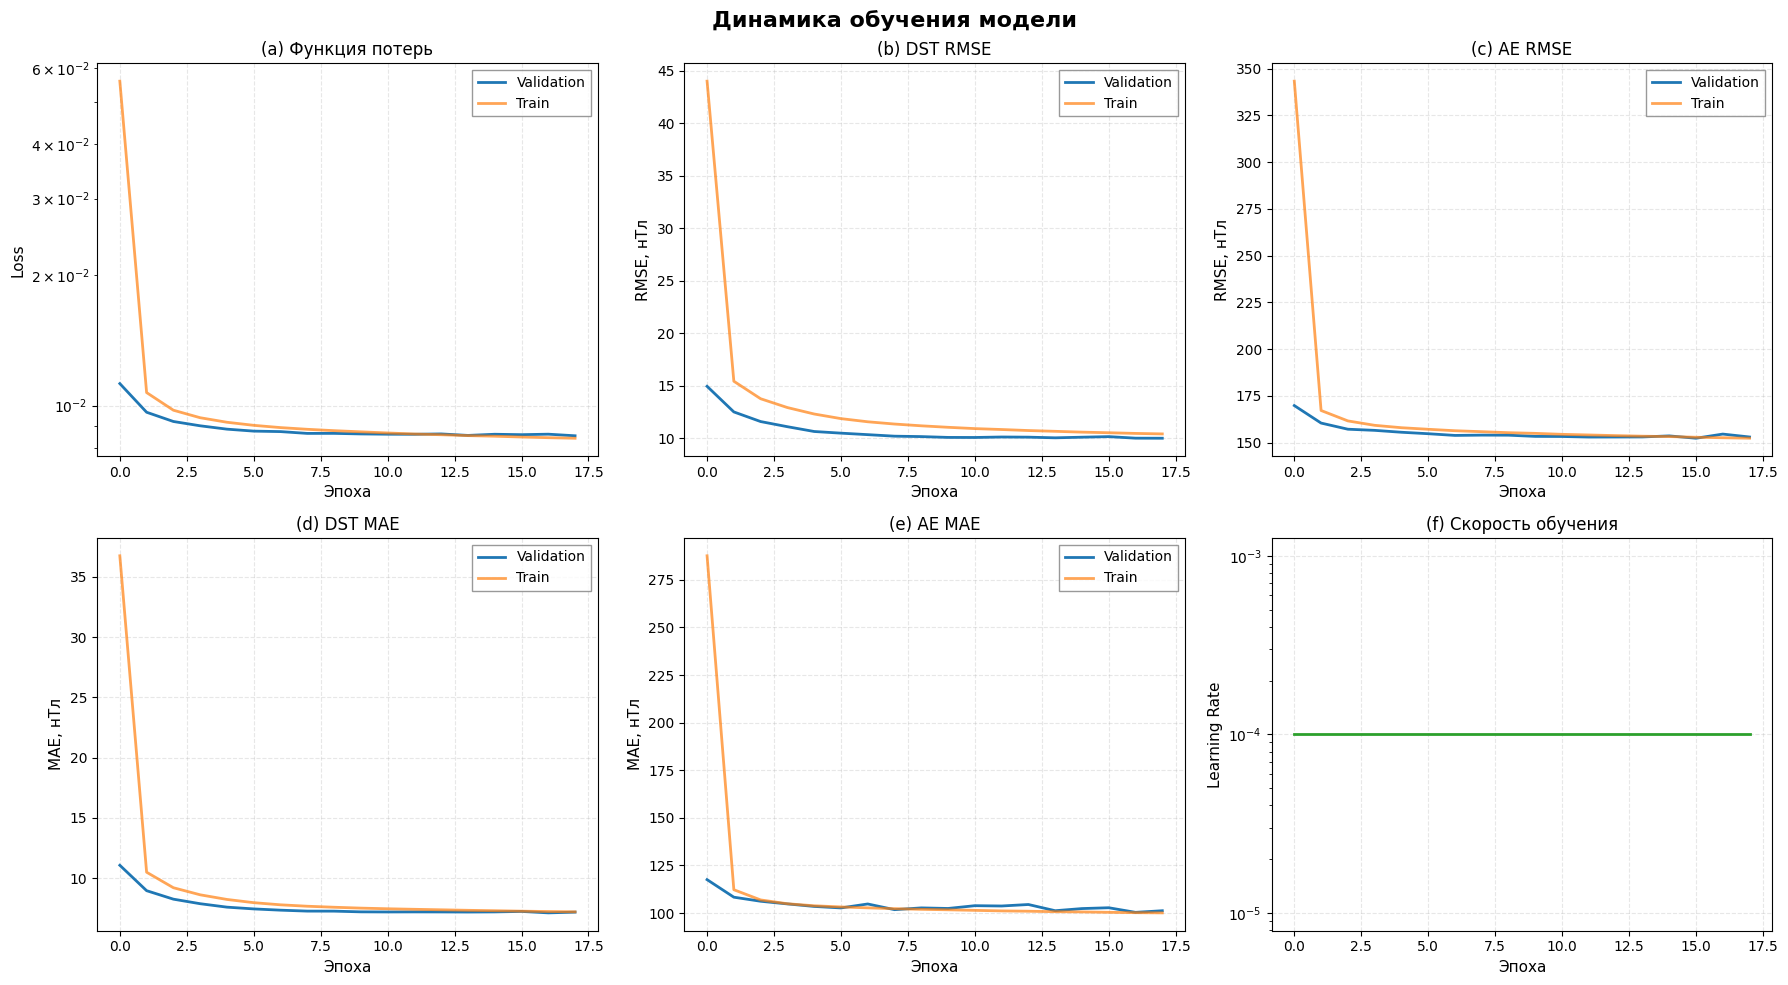

РЕЗУЛЬТАТЫ ОБУЧЕНИЯ

Финальные метрики на валидации:
  Loss:           0.008523
  DST RMSE:       10.007 нТл
  DST MAE:        7.172 нТл
  DST MAPE:       0.638%
  AE RMSE:        152.989 нТл
  AE MAE:         101.219 нТл
  AE MAPE:        0.586%

Лучшие метрики на валидации:
  Лучший Loss:    0.008523 (эпоха 18)
  Лучший DST RMSE: 10.007 нТл (эпоха 18)
  Лучший AE RMSE:  152.323 нТл (эпоха 16)


In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Динамика обучения модели', fontsize=16, fontweight='bold')

# 1. Функция потерь (Loss)
ax = axes[0, 0]
ax.plot(vh['loss'], label='Validation', color='#1f77b4', linewidth=2)
ax.plot(th['summary_loss'], label='Train', color='#ff7f0e', linewidth=2, alpha=0.7)
ax.set_xlabel('Эпоха', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('(a) Функция потерь', fontsize=12, fontweight='medium')
ax.legend(frameon=True, fancybox=False, edgecolor='gray')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_yscale('log')

# 2. DST RMSE
ax = axes[0, 1]
ax.plot(vh['dst']['RMSE'], label='Validation', color='#1f77b4', linewidth=2)
ax.plot(th['dst']['RMSE'], label='Train', color='#ff7f0e', linewidth=2, alpha=0.7)
ax.set_xlabel('Эпоха', fontsize=11)
ax.set_ylabel('RMSE, нТл', fontsize=11)
ax.set_title('(b) DST RMSE', fontsize=12, fontweight='medium')
ax.legend(frameon=True, fancybox=False, edgecolor='gray')
ax.grid(True, alpha=0.3, linestyle='--')

# 3. AE RMSE
ax = axes[0, 2]
ax.plot(vh['ae']['RMSE'], label='Validation', color='#1f77b4', linewidth=2)
ax.plot(th['ae']['RMSE'], label='Train', color='#ff7f0e', linewidth=2, alpha=0.7)
ax.set_xlabel('Эпоха', fontsize=11)
ax.set_ylabel('RMSE, нТл', fontsize=11)
ax.set_title('(c) AE RMSE', fontsize=12, fontweight='medium')
ax.legend(frameon=True, fancybox=False, edgecolor='gray')
ax.grid(True, alpha=0.3, linestyle='--')

# 4. DST MAE
ax = axes[1, 0]
ax.plot(vh['dst']['MAE'], label='Validation', color='#1f77b4', linewidth=2)
ax.plot(th['dst']['MAE'], label='Train', color='#ff7f0e', linewidth=2, alpha=0.7)
ax.set_xlabel('Эпоха', fontsize=11)
ax.set_ylabel('MAE, нТл', fontsize=11)
ax.set_title('(d) DST MAE', fontsize=12, fontweight='medium')
ax.legend(frameon=True, fancybox=False, edgecolor='gray')
ax.grid(True, alpha=0.3, linestyle='--')

# 5. AE MAE
ax = axes[1, 1]
ax.plot(vh['ae']['MAE'], label='Validation', color='#1f77b4', linewidth=2)
ax.plot(th['ae']['MAE'], label='Train', color='#ff7f0e', linewidth=2, alpha=0.7)
ax.set_xlabel('Эпоха', fontsize=11)
ax.set_ylabel('MAE, нТл', fontsize=11)
ax.set_title('(e) AE MAE', fontsize=12, fontweight='medium')
ax.legend(frameon=True, fancybox=False, edgecolor='gray')
ax.grid(True, alpha=0.3, linestyle='--')

# 6. Learning Rate
ax = axes[1, 2]
ax.plot(th['lr'], color='#2ca02c', linewidth=2)
ax.set_xlabel('Эпоха', fontsize=11)
ax.set_ylabel('Learning Rate', fontsize=11)
ax.set_title('(f) Скорость обучения', fontsize=12, fontweight='medium')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

# Вывод финальных метрик
print("="*70)
print("РЕЗУЛЬТАТЫ ОБУЧЕНИЯ")
print("="*70)
print(f"\nФинальные метрики на валидации:")
print(f"  Loss:           {vh['loss'][-1]:.6f}")
print(f"  DST RMSE:       {vh['dst']['RMSE'][-1]:.3f} нТл")
print(f"  DST MAE:        {vh['dst']['MAE'][-1]:.3f} нТл")
print(f"  DST MAPE:       {vh['dst']['MAPE'][-1]:.3f}%")
print(f"  AE RMSE:        {vh['ae']['RMSE'][-1]:.3f} нТл")
print(f"  AE MAE:         {vh['ae']['MAE'][-1]:.3f} нТл")
print(f"  AE MAPE:        {vh['ae']['MAPE'][-1]:.3f}%")

print(f"\nЛучшие метрики на валидации:")
print(f"  Лучший Loss:    {min(vh['loss']):.6f} (эпоха {np.argmin(vh['loss'])+1})")
print(f"  Лучший DST RMSE: {min(vh['dst']['RMSE']):.3f} нТл (эпоха {np.argmin(vh['dst']['RMSE'])+1})")
print(f"  Лучший AE RMSE:  {min(vh['ae']['RMSE']):.3f} нТл (эпоха {np.argmin(vh['ae']['RMSE'])+1})")
print("="*70)

In [24]:
# import joblib

# joblib.dump(X_scaler, "/home/zorinep/workdir/magnesis/notebooks/examples/weights2/GN_X_scaler.joblib")
# joblib.dump(y_scaler, "/home/zorinep/workdir/magnesis/notebooks/examples/weights2/GN_y_scaler.joblib")


In [30]:
summary = visualize_training_results(th, vh, save_dir='./training_plots')

NameError: name 'visualize_training_results' is not defined

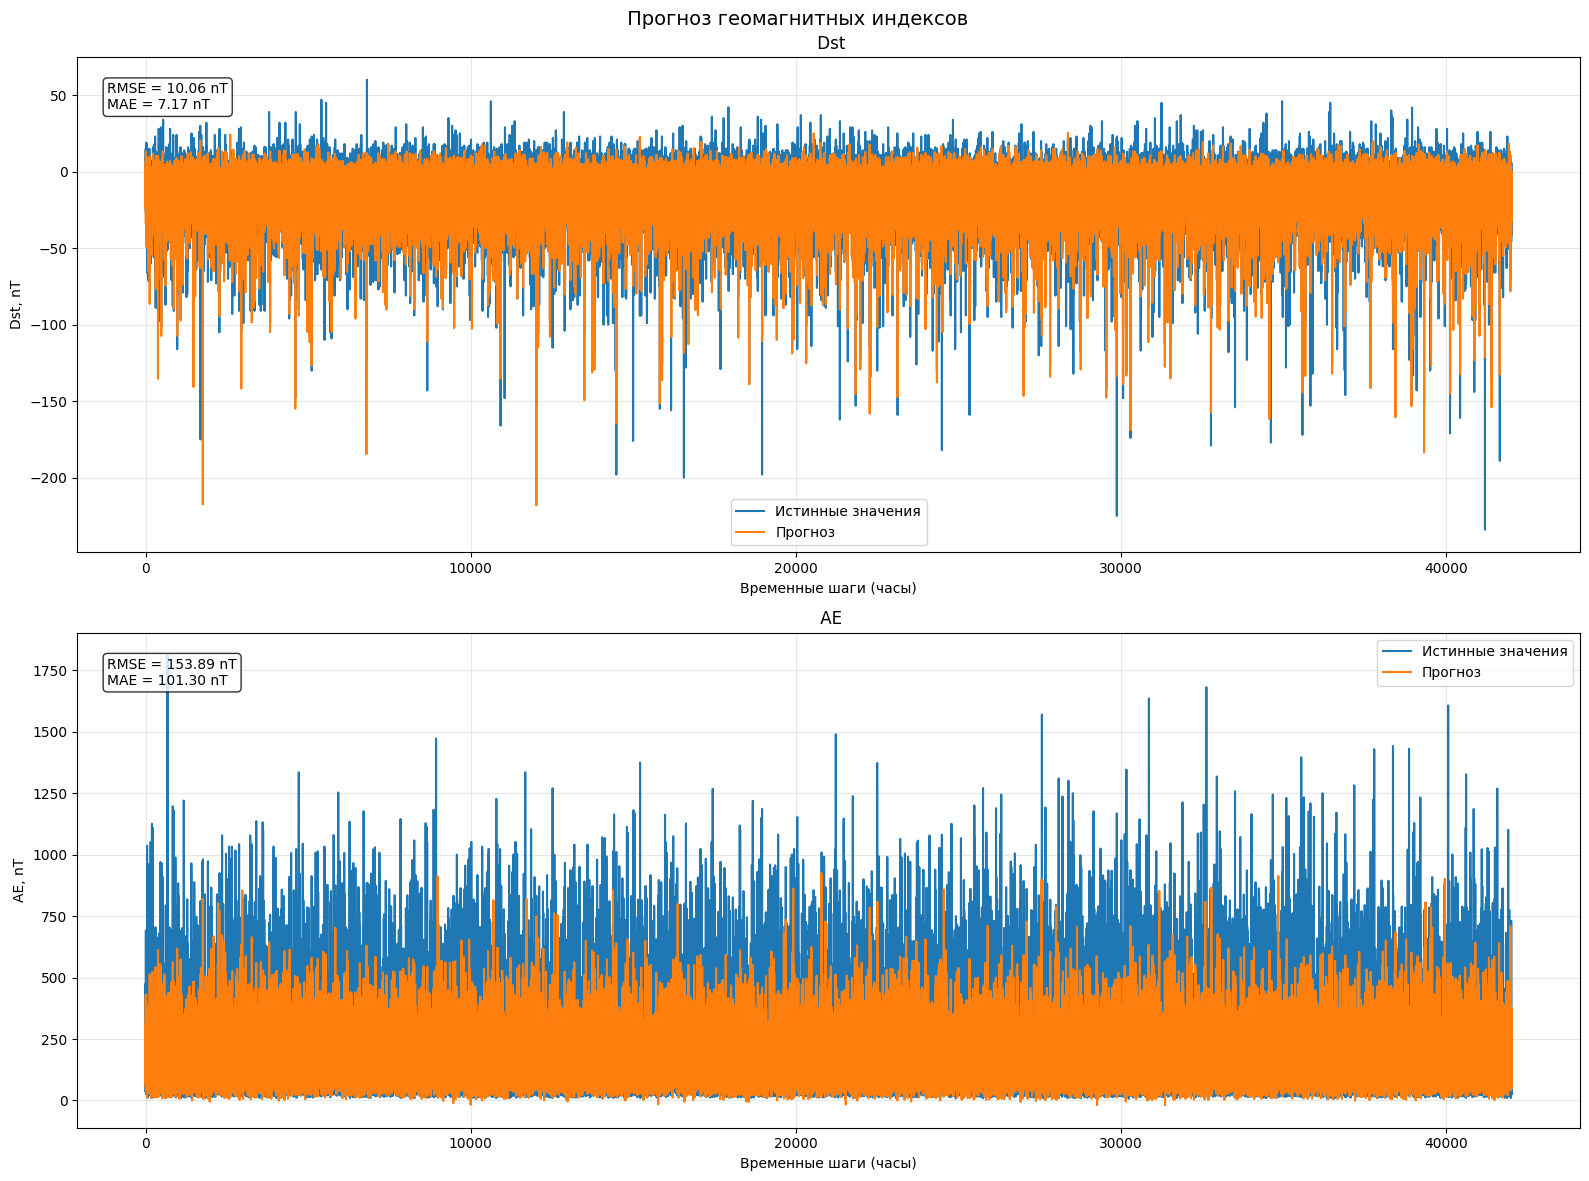

 Результаты прогноза
Dst: RMSE = 10.06 nT, MAE = 7.17 nT
AE:  RMSE = 153.89 nT, MAE = 101.30 nT


{'dst_rmse': np.float32(10.057332),
 'dst_mae': np.float32(7.1748247),
 'ae_rmse': np.float32(153.88632),
 'ae_mae': np.float32(101.296074),
 'dst_preds': array([  1.2125512,  -6.775064 ,  -9.855725 , ...,  -6.396231 ,
        -15.335048 , -11.723509 ], shape=(42023,), dtype=float32),
 'dst_labels': array([  5.9999986,  -6.9999933,  -2.0000045, ...,  -5.000004 ,
        -20.       ,  -3.999994 ], shape=(42023,), dtype=float32),
 'ae_preds': array([ 48.27106 , 148.01106 ,  61.58977 , ...,  48.846794, 304.4177  ,
        209.45035 ], shape=(42023,), dtype=float32),
 'ae_labels': array([ 91.00001 ,  84.00003 ,  33.999977, ...,  25.000002, 196.99997 ,
        212.      ], shape=(42023,), dtype=float32)}

In [33]:
net = GeomagneticModel(
    n_features=19,
    lstm_hidden_size=30,
    lstm_num_layers=1,
    lstm_dropout=0.0,
    dst_attention_heads=5,
    ae_attention_heads=15,
)
net.load_state_dict(torch.load("/home/zorinep/workdir/magnesis/notebooks/time_series_net/train/my_models_last/last_model.pt"))
net.to(device)
inference_on_loader_pipeline(net, val_loader, y_scaler, visualize=True)

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, f1_score

In [28]:
def dst_to_class(dst):
    if isinstance(dst, (int, float)):
        if dst > -50:
            return 0
        elif dst > -100:
            return 1
        elif dst > -200:
            return 2
        else:
            return 3
    
    dst = np.array(dst)
    classes = np.zeros_like(dst, dtype=int)
    classes[dst > -50] = 0
    classes[(dst <= -50) & (dst > -100)] = 1
    classes[(dst <= -100) & (dst > -200)] = 2
    classes[dst <= -200] = 3
    
    return classes

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

In [30]:
dst_labels = result["dst_labels"]
dst_preds = result["dst_preds"]
ae_labels = result["ae_labels"]
ae_preds = result["ae_preds"]

cr = classification_report(dst_to_class(dst_labels), dst_to_class(dst_preds))
print(cr)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     59186
           1       0.48      0.49      0.49      1559
           2       0.46      0.59      0.52       224
           3       0.81      0.54      0.65        46

    accuracy                           0.97     61015
   macro avg       0.68      0.65      0.66     61015
weighted avg       0.97      0.97      0.97     61015

